# Exam 2026 - Problem 2: The Solow model with a time-varying savings rate

We solve Questions 2.1-2.6 using the supplied calibration and a separate model class in `SolowModel.py`. All variables are measured per worker. Production, consumption, and capital accumulation are

$$
y_t=k_t^{\alpha}, \qquad c_t=(1-s_t)y_t, \qquad
k_{t+1}=s_ty_t+(1-\delta)k_t.
$$

Welfare is the discounted sum of log consumption,

$$
W=\sum_{t=0}^{T-1}\beta^t\log(c_t).
$$

The calibration is $\alpha=1/3$, $\delta=0.30$, $\bar{s}=0.25$, $\beta=1/1.2$, $T=100$, and $k_0=0.10$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize

%load_ext autoreload
%autoreload 2

from SolowModel import SolowModelClass

plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 12,
    "figure.figsize": (12, 4),
})
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

model = SolowModelClass()
par = model.par
print(model)

Solow model with:
  alpha = 0.3333 (capital share)
  delta = 0.3000 (depreciation rate)
  s_bar = 0.2500 (long-run savings rate)
  beta  = 0.8333 (discount factor)
  k0    = 0.1000 (initial capital per worker)
  T     = 100 (number of periods)


## 2.1 Question 1

### 2.1.1 Analytical steady state and root-finder

With a constant savings rate $s=\bar{s}$, a positive steady state satisfies

$$
\delta k^*=\bar{s}(k^*)^{\alpha}.
$$

Consequently,

$$
k^*=\left(\frac{\bar{s}}{\delta}\right)^{\frac{1}{1-\alpha}},
\qquad y^*=(k^*)^{\alpha},
\qquad c^*=(1-\bar{s})y^*.
$$

We compute these values analytically and confirm $k^*$ by solving
$\bar{s}f(k)+(1-\delta)k-k=0$ numerically.

In [2]:
k_star, y_star, c_star = model.steady_state()
k_star_numerical = model.solve_steady_state()

steady_state_table = pd.DataFrame(
    {
        "Quantity": [r"$k^*$", r"$y^*$", r"$c^*$", r"$k^*$ (root-finder)"],
        "Value": [k_star, y_star, c_star, k_star_numerical],
    }
)
display(steady_state_table.style.format({"Value": "{:.6f}"}))

assert np.isclose(k_star, k_star_numerical, rtol=1e-10, atol=1e-12)

,Quantity,Value
0,$k^*$,0.760726
1,$y^*$,0.912871
2,$c^*$,0.684653
3,$k^*$ (root-finder),0.760726


The analytical and numerical capital stocks agree to numerical precision. The steady state has $k^*=0.760726$, $y^*=0.912871$, and $c^*=0.684653$.

### 2.1.2 Baseline simulation

We set $s_t=\bar{s}=0.25$ for all $t$ and simulate forward from $k_0=0.10$. Since initial capital is below $k^*$, investment exceeds depreciation and capital converges upward.

,Statistic,Value
0,$c_0$,0.348119
1,$c_{99}$,0.684653
2,$k_{99}$,0.760726


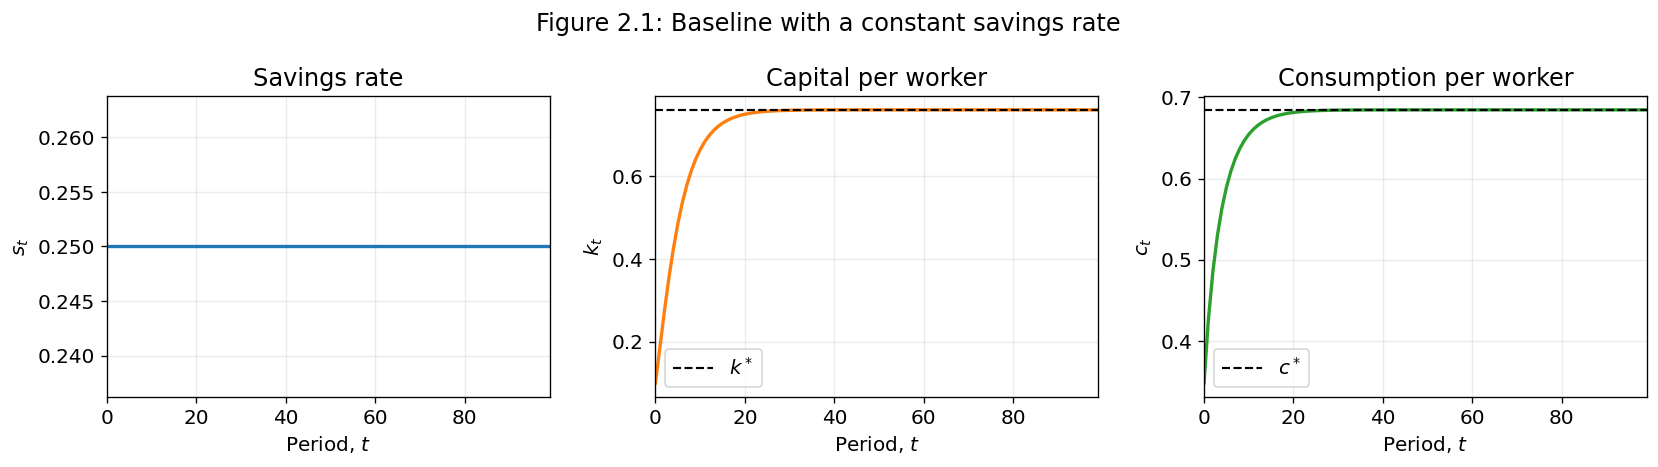

In [3]:
baseline = model.simulate(par.s_bar)
t = np.arange(par.T)

baseline_results = pd.DataFrame(
    {
        "Statistic": [r"$c_0$", rf"$c_{{{par.T-1}}}$", rf"$k_{{{par.T-1}}}$"],
        "Value": [baseline.c[0], baseline.c[-1], baseline.k[-1]],
    }
)
display(baseline_results.style.format({"Value": "{:.6f}"}))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(t, baseline.s, lw=2, color=colors[0])
axes[1].plot(t, baseline.k, lw=2, color=colors[1])
axes[1].axhline(k_star, color="black", ls="--", lw=1.3, label=r"$k^*$")
axes[1].legend()
axes[2].plot(t, baseline.c, lw=2, color=colors[2])
axes[2].axhline(c_star, color="black", ls="--", lw=1.3, label=r"$c^*$")
axes[2].legend()

titles = ["Savings rate", "Capital per worker", "Consumption per worker"]
ylabels = [r"$s_t$", r"$k_t$", r"$c_t$"]
for ax, title, ylabel in zip(axes, titles, ylabels):
    ax.set(title=title, xlabel=r"Period, $t$", ylabel=ylabel, xlim=(0, par.T - 1))

fig.suptitle("Figure 2.1: Baseline with a constant savings rate")
fig.tight_layout()
plt.show()

**Comment on Figure 2.1.** The constant savings rate makes capital and consumption rise monotonically from the low initial capital stock. By the end of the simulation, both paths are practically at their steady-state levels.

### 2.1.3 Tests of the simulator

We test cases with known answers instead of testing against the preceding numerical output. First, an economy starting at $k^*$ must remain there. Second, with $s_t=0$, the exact path is $k_t=(1-\delta)^t k_0$. We also verify the resource identity $y_t=c_t+i_t$.

In [4]:
# Test 1: a steady-state economy remains in the steady state.
sim_steady = model.simulate(par.s_bar, k0=k_star)
assert np.allclose(sim_steady.k, k_star, rtol=1e-10, atol=1e-12)

# Test 2: without investment, capital only depreciates.
sim_zero_saving = model.simulate(0.0)
k_known = par.k0 * (1 - par.delta) ** t
assert np.allclose(sim_zero_saving.k, k_known, rtol=1e-10, atol=1e-12)

# Test 3: output is allocated between consumption and investment.
assert np.allclose(baseline.y, baseline.c + baseline.i)

print("All simulator tests passed.")

All simulator tests passed.


## 2.2 Question 2

### 2.2.1 Implementation of the savings rule

We implement equation (6) as

$$
s_t=\bar{s}+(s_0-\bar{s})\phi^t.
$$

The expression implies $s_0$ in period 0 and $s_t\to\bar{s}$ because $0\leq\phi<1$. The method `s_path` in `SolowModel.py` constructs the full path.

In [5]:
combinations = [(0.30, 0.50), (0.40, 0.80), (0.10, 0.50), (0.60, 0.60)]

savings_check = []
for s0, phi in combinations:
    s = model.s_path(s0, phi)
    savings_check.append(
        {r"$s_0$": s0, r"$\phi$": phi, r"realized $s_0$": s[0], rf"$s_{{{par.T-1}}}$": s[-1]}
    )

display(pd.DataFrame(savings_check).style.format("{:.6f}"))

,$s_0$,$\phi$,realized $s_0$,$s_{99}$
0,0.300000,0.500000,0.300000,0.250000
1,0.400000,0.800000,0.400000,0.250000
2,0.100000,0.500000,0.100000,0.250000
3,0.600000,0.600000,0.600000,0.250000


### 2.2.2 Simulation of the four combinations

We simulate all four rules and compare their savings, capital, and consumption paths with the baseline in the same three panels.

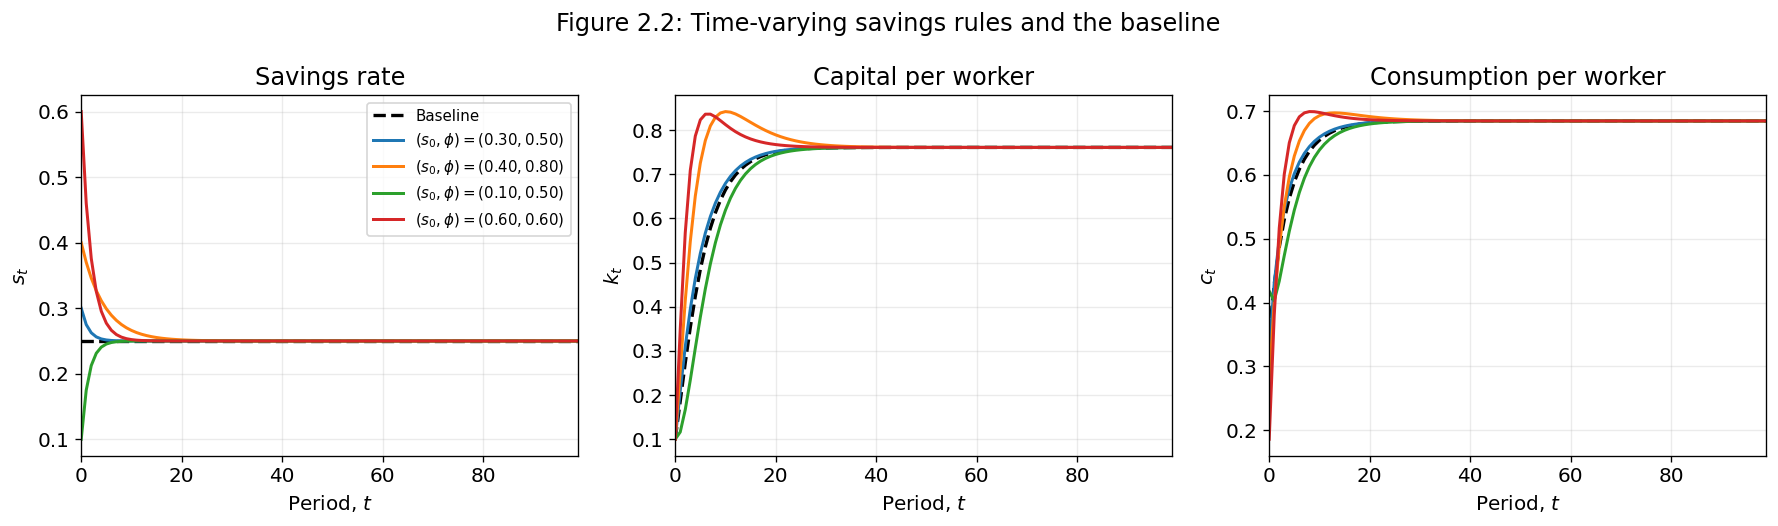

In [6]:
scenario_sims = {}
for s0, phi in combinations:
    scenario_sims[(s0, phi)] = model.simulate(model.s_path(s0, phi))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, variable, ylabel in zip(
    axes, ["s", "k", "c"], [r"$s_t$", r"$k_t$", r"$c_t$"]
):
    ax.plot(t, getattr(baseline, variable), color="black", ls="--", lw=2, label="Baseline")
    for index, ((s0, phi), sim) in enumerate(scenario_sims.items()):
        ax.plot(
            t,
            getattr(sim, variable),
            lw=1.8,
            color=colors[index],
            label=fr"$(s_0,\phi)=({s0:.2f},{phi:.2f})$",
        )
    ax.set(xlabel=r"Period, $t$", ylabel=ylabel, xlim=(0, par.T - 1))

axes[0].set_title("Savings rate")
axes[1].set_title("Capital per worker")
axes[2].set_title("Consumption per worker")
axes[0].legend(fontsize=9)
fig.suptitle("Figure 2.2: Time-varying savings rules and the baseline")
fig.tight_layout()
plt.show()

**Comment on Figure 2.2.** A higher initial savings rate lowers consumption immediately but builds more capital and output in subsequent periods; a lower $s_0$ produces the reverse pattern. All paths eventually merge with the baseline because every rule converges to $\bar{s}=0.25$.

### 2.2.3 Terminal capital

We report $k_{T-1}$ for the baseline and the four time-varying rules.

In [7]:
capital_rows = [{"Rule": "Baseline", rf"$k_{{{par.T-1}}}$": baseline.k[-1]}]
for (s0, phi), sim in scenario_sims.items():
    capital_rows.append(
        {
            "Rule": fr"$(s_0,\phi)=({s0:.2f},{phi:.2f})$",
            rf"$k_{{{par.T-1}}}$": sim.k[-1],
        }
    )

terminal_capital = pd.DataFrame(capital_rows)
display(terminal_capital.style.format({rf"$k_{{{par.T-1}}}$": "{:.9f}"}))

,Rule,$k_{99}$
0,Baseline,0.760725774
1,"$(s_0,\phi)=(0.30,0.50)$",0.760725774
2,"$(s_0,\phi)=(0.40,0.80)$",0.760725778
3,"$(s_0,\phi)=(0.10,0.50)$",0.760725774
4,"$(s_0,\phi)=(0.60,0.60)$",0.760725774


The terminal values are equal up to economically irrelevant numerical differences. This is not accidental: $\phi^t\to0$ implies $s_t\to\bar{s}$, so every economy converges to the same steady state $k^*(\bar{s})$.

### 2.2.4 Economic roles of $s_0$ and $\phi$

- $s_0$ controls the initial allocation of output. Since $k_0$ and therefore $y_0$ are predetermined, a larger $s_0$ lowers $c_0=(1-s_0)y_0$ one-for-one in the savings share, but raises $k_1$ and future productive capacity.
- $\phi$ controls persistence because $s_t-\bar{s}=(s_0-\bar{s})\phi^t$. A larger $\phi$ makes the initial deviation disappear more slowly. It therefore prolongs high saving when $s_0>\bar{s}$ and prolongs low saving when $s_0<\bar{s}$.
- Neither parameter changes the eventual steady state in this two-parameter rule. They only change the transition toward it.

## 2.3 Question 3

### 2.3.1 Implementation of welfare

The method `welfare` computes

$$
W=\sum_{t=0}^{T-1}\beta^t\log(c_t).
$$

Log utility rewards consumption at every date and strongly penalizes very low consumption. Since $\beta<1$, early changes in consumption receive more weight than equally sized later changes.

In [8]:
W_baseline = model.welfare(baseline.c)
print(f"Baseline welfare: W = {W_baseline:.9f}")

Baseline welfare: W = -3.994387669


### 2.3.2 Welfare comparison

We calculate $W$ for each rule and its difference from baseline welfare.

In [9]:
welfare_rows = [{"Rule": "Baseline", r"$W$": W_baseline, r"$W-W_{baseline}$": 0.0}]
for (s0, phi), sim in scenario_sims.items():
    W_now = model.welfare(sim.c)
    welfare_rows.append(
        {
            "Rule": fr"$(s_0,\phi)=({s0:.2f},{phi:.2f})$",
            r"$W$": W_now,
            r"$W-W_{baseline}$": W_now - W_baseline,
        }
    )

welfare_table = pd.DataFrame(welfare_rows)
display(welfare_table.style.format({r"$W$": "{:.9f}", r"$W-W_{baseline}$": "{:+.9f}"}))

,Rule,$W$,$W-W_{baseline}$
0,Baseline,-3.994387669,+0.000000000
1,"$(s_0,\phi)=(0.30,0.50)$",-3.985706160,+0.008681508
2,"$(s_0,\phi)=(0.40,0.80)$",-4.091412540,-0.097024871
3,"$(s_0,\phi)=(0.10,0.50)$",-4.146017643,-0.151629975
4,"$(s_0,\phi)=(0.60,0.60)$",-4.340652740,-0.346265072


### 2.3.3 Ranking the four rules

Only $(s_0,\phi)=(0.30,0.50)$ gives higher welfare than the baseline, with $\Delta W=0.008682$. We could not determine the ranking reliably from Figure 2.2 alone: the consumption paths cross, while $W$ applies both the nonlinear transformation $\log(c_t)$ and the time weights $\beta^t$. The welfare calculation is therefore necessary.

## 2.4 Question 4

### 2.4.1 Welfare on a grid

We use 121 values of $s_0$ on $[0,0.60]$ and 96 values of $\phi$ on $[0,0.95]$. The grid spacings are therefore $0.005$ and $0.01$.

Best grid point: s0 = 0.310, phi = 0.230
W at the best grid point = -3.984306002


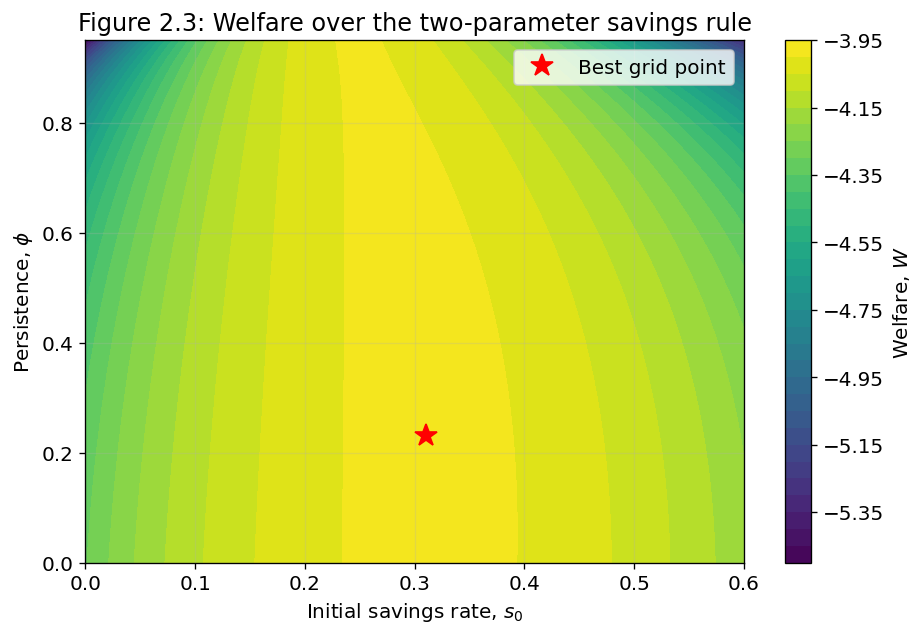

In [10]:
s0_grid = np.linspace(0.00, 0.60, 121)
phi_grid = np.linspace(0.00, 0.95, 96)
W_grid = model.grid_welfare(s0_grid, phi_grid)

best_index = np.unravel_index(np.argmax(W_grid), W_grid.shape)
phi_grid_best = phi_grid[best_index[0]]
s0_grid_best = s0_grid[best_index[1]]
W_grid_best = W_grid[best_index]

print(f"Best grid point: s0 = {s0_grid_best:.3f}, phi = {phi_grid_best:.3f}")
print(f"W at the best grid point = {W_grid_best:.9f}")

S0, PHI = np.meshgrid(s0_grid, phi_grid)
fig, ax = plt.subplots(figsize=(8, 5.5))
contour = ax.contourf(S0, PHI, W_grid, levels=30, cmap="viridis")
ax.plot(s0_grid_best, phi_grid_best, "r*", ms=14, label="Best grid point")
ax.set(
    title="Figure 2.3: Welfare over the two-parameter savings rule",
    xlabel=r"Initial savings rate, $s_0$",
    ylabel=r"Persistence, $\phi$",
)
ax.legend()
fig.colorbar(contour, ax=ax, label=r"Welfare, $W$")
fig.tight_layout()
plt.show()

**Comment on Figure 2.3.** Welfare is maximized in a small interior region around $s_0\approx0.31$ and $\phi\approx0.22$. Moving away from this region either sacrifices too much initial consumption or builds capital too slowly to compensate for the early loss.

### 2.4.2 Numerical optimization

We use the best grid point as the initial guess for a bounded L-BFGS-B optimizer. The bounds match the grid, so the two numerical methods solve the same constrained problem.

In [11]:
objective_2 = lambda x: -model.evaluate(x[0], x[1])
result_2 = optimize.minimize(
    objective_2,
    x0=np.array([s0_grid_best, phi_grid_best]),
    method="L-BFGS-B",
    bounds=((0.00, 0.60), (0.00, 0.95)),
    options={"ftol": 1e-14, "gtol": 1e-10, "maxiter": 5_000, "maxls": 50},
)
assert result_2.success, result_2.message

s0_opt_2, phi_opt_2 = result_2.x
W_opt_2 = -result_2.fun

optimization_2_table = pd.DataFrame(
    {
        "Method": ["Grid", "L-BFGS-B"],
        r"$s_0$": [s0_grid_best, s0_opt_2],
        r"$\phi$": [phi_grid_best, phi_opt_2],
        r"$W$": [W_grid_best, W_opt_2],
    }
)
display(optimization_2_table.style.format({r"$s_0$": "{:.6f}", r"$\phi$": "{:.6f}", r"$W$": "{:.9f}"}))
print(f"Optimizer gain relative to the grid: {W_opt_2 - W_grid_best:.9f}")

Optimizer gain relative to the grid: 0.000005709


,Method,$s_0$,$\phi$,$W$
0,Grid,0.310000,0.230000,-3.984306002
1,L-BFGS-B,0.311497,0.220770,-3.984300292


The optimizer finds $(s_0,\phi)=(0.311497,0.220770)$ and $W=-3.984300292$. This is only $0.000005709$ above the grid result, which confirms that the grid was already fine enough to locate the relevant optimum but not to estimate it at full precision.

### 2.4.3 Best two-parameter rule compared with the baseline

We simulate the optimized rule and find the first period in which optimized consumption is strictly above baseline consumption.

Consumption under the best rule in period 0: c0 = 0.319575
Baseline consumption in period 0:             c0 = 0.348119
First period with c_t above baseline:         t = 1


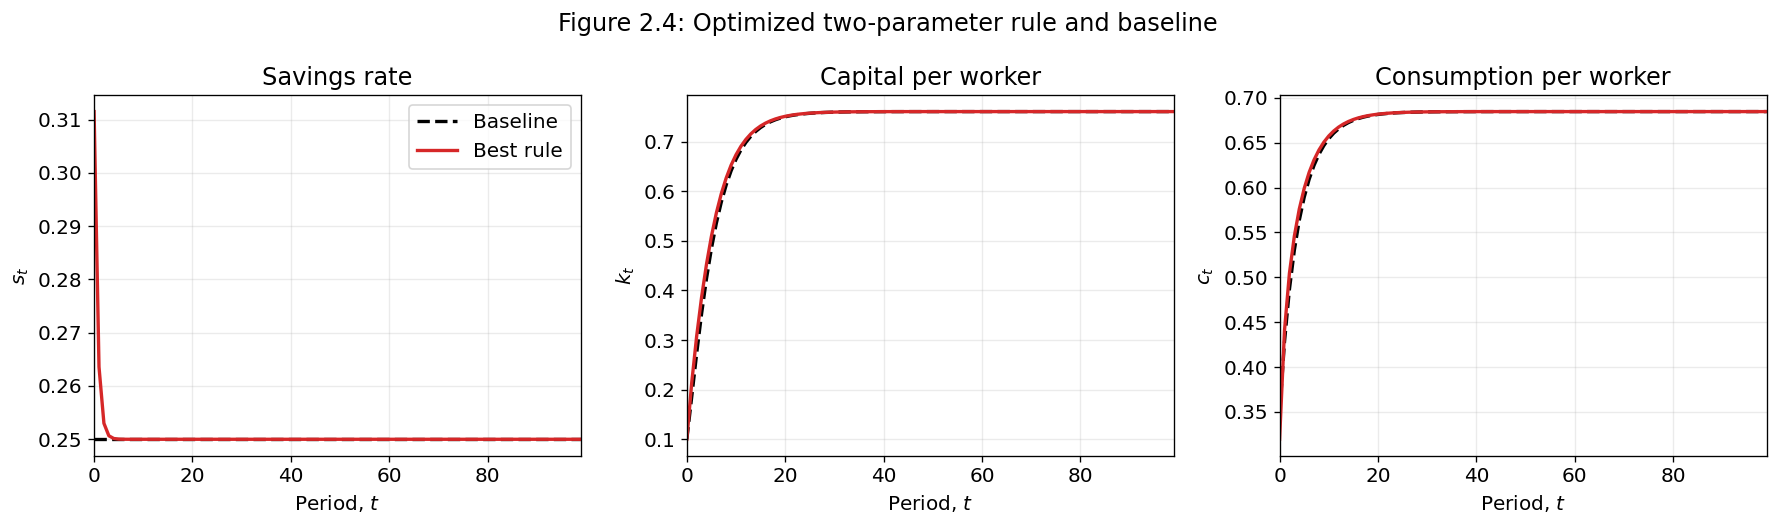

In [12]:
best_two_parameter = model.simulate(model.s_path(s0_opt_2, phi_opt_2))
periods_above = np.flatnonzero(best_two_parameter.c > baseline.c)
first_period_above = int(periods_above[0]) if periods_above.size else None

print(f"Consumption under the best rule in period 0: c0 = {best_two_parameter.c[0]:.6f}")
print(f"Baseline consumption in period 0:             c0 = {baseline.c[0]:.6f}")
print(f"First period with c_t above baseline:         t = {first_period_above}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, variable, ylabel in zip(
    axes, ["s", "k", "c"], [r"$s_t$", r"$k_t$", r"$c_t$"]
):
    ax.plot(t, getattr(baseline, variable), color="black", ls="--", lw=2, label="Baseline")
    ax.plot(t, getattr(best_two_parameter, variable), color=colors[3], lw=2, label="Best rule")
    ax.set(xlabel=r"Period, $t$", ylabel=ylabel, xlim=(0, par.T - 1))

axes[0].set_title("Savings rate")
axes[1].set_title("Capital per worker")
axes[2].set_title("Consumption per worker")
axes[0].legend()
fig.suptitle("Figure 2.4: Optimized two-parameter rule and baseline")
fig.tight_layout()
plt.show()

**Comment on Figure 2.4.** The optimized rule sacrifices consumption at $t=0$ by saving more, but the extra capital raises consumption above baseline already at $t=1$. Because $\phi$ is low, the savings rate returns rapidly to $\bar{s}$ and the long-run paths coincide.

## 2.5 Question 5

### 2.5.1 Optimization over $(s_0,\phi,s_\infty)$

We generalize the rule to

$$
s_t=s_\infty+(s_0-s_\infty)\phi^t.
$$

We minimize $-W$ with bounds $0\leq s_0,s_\infty<1$ and $0\leq\phi<1$. To reduce dependence on one initial guess, we run L-BFGS-B from several starting points and keep the best successful result.

In [13]:
upper = 1 - 1e-10
objective_3 = lambda x: -model.evaluate(x[0], x[1], s_inf=x[2])
bounds_3 = ((0.00, upper), (0.00, upper), (0.00, upper))
starts_3 = [
    np.array([s0_opt_2, phi_opt_2, par.s_bar]),
    np.array([0.50, 0.70, 0.20]),
    np.array([0.30, 0.50, 0.20]),
    np.array([0.70, 0.90, 0.20]),
    np.array([0.60, 0.40, 0.20]),
]

results_3 = [
    optimize.minimize(
        objective_3,
        x0=x0,
        method="L-BFGS-B",
        bounds=bounds_3,
        options={"ftol": 1e-14, "gtol": 1e-10, "maxiter": 5_000, "maxls": 50},
    )
    for x0 in starts_3
]
successful_3 = [result for result in results_3 if result.success]
assert successful_3, "No three-parameter optimization converged."
result_3 = min(successful_3, key=lambda result: result.fun)

s0_opt_3, phi_opt_3, s_inf_opt_3 = result_3.x
W_opt_3 = -result_3.fun

three_parameter_table = pd.DataFrame(
    {
        "Parameter": [r"$s_0$", r"$\phi$", r"$s_\infty$", r"$W$", r"$W-W_{Q4}$"],
        "Value": [s0_opt_3, phi_opt_3, s_inf_opt_3, W_opt_3, W_opt_3 - W_opt_2],
    }
)
display(three_parameter_table.style.format({"Value": "{:.9f}"}))

,Parameter,Value
0,$s_0$,0.313859307
1,$\phi$,0.670774246
2,$s_\infty$,0.198943859
3,$W$,-3.966965448
4,$W-W_{Q4}$,0.017334844


The optimum is approximately $(s_0,\phi,s_\infty)=(0.313859,0.670774,0.198944)$ with $W=-3.966965448$. Allowing the long-run savings rate to adjust raises welfare by $0.017334844$ relative to Question 2.4. The rule saves relatively much while capital is scarce, then converges to a long-run savings rate close to $0.20$.

### 2.5.2 Terminal capital and the steady state from Question 2.1

We compare $k_{T-1}$ under the optimized three-parameter rule with the baseline steady state based on $\bar{s}=0.25$.

In [14]:
best_three_parameter = model.simulate(model.s_path(s0_opt_3, phi_opt_3, s_inf=s_inf_opt_3))
k_terminal_3 = best_three_parameter.k[-1]
k_star_3 = model.steady_state(s_inf_opt_3)[0]

capital_comparison = pd.DataFrame(
    {
        "Capital measure": [
            rf"Optimized $k_{{{par.T-1}}}$",
            r"Steady state implied by optimized $s_\infty$",
            r"Question 2.1 steady state based on $\bar{s}$",
        ],
        "Value": [k_terminal_3, k_star_3, k_star],
    }
)
display(capital_comparison.style.format({"Value": "{:.6f}"}))

,Capital measure,Value
0,Optimized $k_{99}$,0.540025
1,Steady state implied by optimized $s_\infty$,0.540025
2,Question 2.1 steady state based on $\bar{s}$,0.760726


They are not the same, and they should not be. Question 2.1 fixes the long-run savings rate at $\bar{s}=0.25$, whereas the optimizer chooses $s_\infty\approx0.199$. Hence the optimized path converges to a lower steady-state capital stock near $0.540$, not to $0.761$.

The result also has a clear intertemporal interpretation. For an unrestricted consumption-savings choice, the discounted steady-state condition is

$$
1=\beta\left[f'(k)+(1-\delta)\right].
$$

With the present calibration it implies $k\approx0.544$ and a savings rate near $0.20$, close to the numerical result. Discounting therefore makes the welfare-relevant long-run capital stock lower than the consumption-maximizing golden-rule stock and lower than the baseline steady state.

## 2.6 Question 6

### 2.6.1 Alternative functional form

We propose the stretched-exponential rule

$$
s_t=s_\infty+(s_0-s_\infty)\phi^{t^p},
\qquad p>0.
$$

It starts at $s_0$, remains between $s_0$ and $s_\infty$, and converges to the constant $s_\infty$ for $0\leq\phi<1$. It nests Question 2.5 when $p=1$, while $p$ adds flexibility to the curvature and speed of the transition.

### 2.6.2 Implementation and optimized welfare

The methods `stretched_s_path` and `evaluate_stretched` implement the alternative. Since $p=1$ reproduces the best rule from Question 2.5, we use that nested solution as the initial guess and optimize all four parameters.

In [15]:
objective_4 = lambda x: -model.evaluate_stretched(x[0], x[1], x[2], x[3])
result_4 = optimize.minimize(
    objective_4,
    x0=np.array([s0_opt_3, phi_opt_3, s_inf_opt_3, 1.0]),
    method="L-BFGS-B",
    bounds=((0.00, upper), (1e-10, upper), (0.00, upper), (0.10, 5.00)),
    options={"ftol": 1e-15, "gtol": 1e-10, "maxiter": 5_000, "maxls": 50},
)
assert result_4.success, result_4.message

s0_alt, phi_alt, s_inf_alt, power_alt = result_4.x
W_alt = -result_4.fun
assert W_alt >= W_opt_3 - 1e-10

alternative_parameters = pd.DataFrame(
    {
        "Parameter": [r"$s_0$", r"$\phi$", r"$s_\infty$", r"$p$", r"$W$"],
        "Value": [s0_alt, phi_alt, s_inf_alt, power_alt, W_alt],
    }
)
display(alternative_parameters.style.format({"Value": "{:.9f}"}))

,Parameter,Value
0,$s_0$,0.312971058
1,$\phi$,0.690037473
2,$s_\infty$,0.200134334
3,$p$,1.090789316
4,$W$,-3.966951429


### 2.6.3 Comparison with Questions 2.4 and 2.5

We place the three optimized welfare levels in one table.

In [16]:
final_comparison = pd.DataFrame(
    {
        "Rule": [
            "Question 2.4: two parameters",
            "Question 2.5: three parameters",
            "Question 2.6: stretched exponential",
        ],
        r"$W$": [W_opt_2, W_opt_3, W_alt],
        r"Gain relative to Question 2.4": [0.0, W_opt_3 - W_opt_2, W_alt - W_opt_2],
        r"Gain relative to Question 2.5": [W_opt_2 - W_opt_3, 0.0, W_alt - W_opt_3],
    }
)
display(
    final_comparison.style.format(
        {
            r"$W$": "{:.9f}",
            r"Gain relative to Question 2.4": "{:+.9f}",
            r"Gain relative to Question 2.5": "{:+.9f}",
        }
    )
)

,Rule,$W$,Gain relative to Question 2.4,Gain relative to Question 2.5
0,Question 2.4: two parameters,-3.984300292,+0.000000000,-0.017334844
1,Question 2.5: three parameters,-3.966965448,+0.017334844,+0.000000000
2,Question 2.6: stretched exponential,-3.966951429,+0.017348863,+0.000014019


Yes, the alternative rule beats both earlier optimized rules. It improves welfare by about $0.000014$ relative to Question 2.5. The gain is small because the estimated $p\approx1.091$ is close to one, showing that the single exponential in Question 2.5 was already a very good approximation to the preferred transition path.